# Physics-Informed Neural Network: Damped Harmonic Oscillator

A PINN built in TensorFlow that models a damped harmonic oscillator by training
against its governing differential equation `m*x'' + c*x' + k*x = 0`

## 1. Parameters

In [11]:
import numpy as np
import pandas as pd

# Load training data
df_train = pd.read_csv('train.csv')

m = 1.0  #@param {type:"float"} # mass (kg)
k = 1.0  #@param {type:"float"} # spring constant (N/m)
c = 0.1  #@param {type:"float"} # damping coefficient (Ns/m)

# Training domain
t_min = 0.0
t_max = 30.0

x0 = df_train['displacement'].iloc[0] # initial displacement (m)
v0 = df_train['velocity'].iloc[0]     # initial velocity (m/s)

omega_n = np.sqrt(k / m)
zeta = c / (2 * np.sqrt(m * k))
omega_d = omega_n * np.sqrt(1 - zeta**2)

print(f"Mass (m): {m} kg")
print(f"Spring constant (k): {k} N/m")
print(f"Damping coefficient (c): {c} Ns/m")
print(f"Initial displacement (x0): {x0} m")
print(f"Initial velocity (v0): {v0} m/s")
print()
print(f"Natural frequency (omega_n): {omega_n:.4f} rad/s")
print(f"Damping ratio (zeta): {zeta:.4f}" + ("  -- underdamped" if zeta < 1 else ""))
print(f"Damped frequency (omega_d): {omega_d:.4f} rad/s")
print(f"Period: {2 * np.pi / omega_d:.4f} s")
print(f"Domain [{t_min}, {t_max}] covers {(t_max - t_min) / (2 * np.pi / omega_d):.1f} oscillations")

Mass (m): 1.0 kg
Spring constant (k): 1.0 N/m
Damping coefficient (c): 0.1 Ns/m
Initial displacement (x0): 1.0 m
Initial velocity (v0): 0.0 m/s

Natural frequency (omega_n): 1.0000 rad/s
Damping ratio (zeta): 0.0500  -- underdamped
Damped frequency (omega_d): 0.9987 rad/s
Period: 6.2911 s
Domain [0.0, 30.0] covers 4.8 oscillations


## 2. Verify the dataset parameters

In [12]:
# Solve for the coefficients
A_fit = np.column_stack([-df_train['velocity'].values, -df_train['displacement'].values])
b_fit = df_train['acceleration'].values
(c_over_m, k_over_m), *_ = np.linalg.lstsq(A_fit, b_fit, rcond=None)

print(f"Recovered from data:  c/m = {c_over_m:.6f}   k/m = {k_over_m:.6f}")
print(f"Values in use:        c/m = {c / m:.6f}   k/m = {k / m:.6f}")

assert np.isclose(c_over_m, c / m, atol=1e-4), "damping coefficient does not match the data"
assert np.isclose(k_over_m, k / m, atol=1e-4), "spring constant does not match the data"
print("\nParameters match the dataset.")

Recovered from data:  c/m = 0.100000   k/m = 1.000000
Values in use:        c/m = 0.100000   k/m = 1.000000

Parameters match the dataset.


In [13]:
#@title Analytical Solution
import numpy as np

def analytical_solution(t, m, k, c, x0, v0):
    omega_n = np.sqrt(k / m)
    zeta = c / (2 * np.sqrt(m * k))


    omega_d = omega_n * np.sqrt(1 - zeta**2)

    A = x0
    B = (v0 + zeta * omega_n * x0) / omega_d

    x_t = np.exp(-zeta * omega_n * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))
    return x_t

t_test = np.linspace(0, 10, 100)
x_analytical = analytical_solution(t_test, m, k, c, x0, v0)

print("Analytical solution function defined and tested.")
print(f"Example x(0) = {analytical_solution(0, m, k, c, x0, v0):.4f}")
print(f"Example x(1) = {analytical_solution(1, m, k, c, x0, v0):.4f}")

Analytical solution function defined and tested.
Example x(0) = 1.0000
Example x(1) = 0.5550


## 3. Network

In [14]:
#@title Neural Network Setup
import tensorflow as tf

class PINNModel(tf.keras.Model):
    def __init__(self, t_min=0.0, t_max=30.0):
        super(PINNModel, self).__init__()
        self.t_mid = (t_max + t_min) / 2.0
        self.t_half = (t_max - t_min) / 2.0
        self.dense1 = tf.keras.layers.Dense(units=128, activation='tanh', name='dense_1')
        self.dense2 = tf.keras.layers.Dense(units=128, activation='tanh', name='dense_2')
        self.dense3 = tf.keras.layers.Dense(units=128, activation='tanh', name='dense_3')
        self.output_layer = tf.keras.layers.Dense(units=1, name='output_layer')

    def call(self, inputs):
        x = (inputs - self.t_mid) / self.t_half
        x = self.dense1(x)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.output_layer(x)


model = PINNModel(t_min, t_max)

dummy_input = tf.zeros((1, 1))
_ = model(dummy_input)

print("Neural Network Model Summary:")
model.summary()

Neural Network Model Summary:


Model: "pinn_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (1, 128)               │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 128)               │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 128)               │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (1, 1)                 │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,409 (130.50 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Observed data points


In [15]:
#@title Prepare training data for PINN (observed data points)
# Restrict observed data to the domain where the ODE residual is enforced
mask = (df_train['time'] >= t_min) & (df_train['time'] <= t_max)
df_window = df_train.loc[mask]

t_train_data_np = df_window['time'].values.astype(np.float32)
x_train_data_np = df_window['displacement'].values.astype(np.float32)

print(f"t_train_data_np shape: {t_train_data_np.shape}")
print(f"x_train_data_np shape: {x_train_data_np.shape}")
print(f"Using {len(df_window)} of {len(df_train)} rows (t in [{t_min}, {t_max}])")

t_train_data_np shape: (20,)
x_train_data_np shape: (20,)
Using 20 of 200 rows (t in [0.0, 30.0])


## 6. Loss terms

Four terms, all computed with automatic differentiation:

| Term | Enforces |
|---|---|
| `ode_loss` | `m*x'' + c*x' + k*x = 0` across the collocation points |
| `initial_displacement_loss` | `x(0) = x0` |
| `initial_velocity_loss` | `x'(0) = v0` |
| `data_loss` | predictions match the observed points |


In [16]:
#@title Compute PINN Losses
import tensorflow as tf

def compute_pinn_losses(t, model, m, k, c, x0, v0, t_train=None, x_train=None):

    t_tensor_batch = tf.constant(t, dtype=tf.float32)
    t_reshaped_batch = tf.reshape(t_tensor_batch, (-1, 1))

    with tf.GradientTape() as tape2:
        tape2.watch(t_reshaped_batch)
        with tf.GradientTape() as tape1:
            tape1.watch(t_reshaped_batch)
            x_pred = model(t_reshaped_batch)
        dx_dt_pred = tape1.gradient(x_pred, t_reshaped_batch)
    d2x_dt2_pred = tape2.gradient(dx_dt_pred, t_reshaped_batch)

    ode_residual = m * tf.squeeze(d2x_dt2_pred) + c * tf.squeeze(dx_dt_pred) + k * tf.squeeze(x_pred)

    ode_loss = tf.reduce_mean(tf.square(ode_residual))

    t_initial_reshaped = tf.constant([[0.0]], dtype=tf.float32)
    x_pred_0 = model(t_initial_reshaped)
    initial_displacement_loss = tf.square(tf.squeeze(x_pred_0) - x0)

    with tf.GradientTape() as tape_ic_vel:
        tape_ic_vel.watch(t_initial_reshaped)
        x_pred_ic_vel = model(t_initial_reshaped)
    dx_dt_pred_0 = tape_ic_vel.gradient(x_pred_ic_vel, t_initial_reshaped)

    initial_velocity_loss = tf.square(tf.squeeze(dx_dt_pred_0) - v0)

    data_loss = tf.constant(0.0, dtype=tf.float32)
    if t_train is not None and x_train is not None:
        t_train_tf = tf.constant(t_train, dtype=tf.float32)
        t_train_reshaped = tf.reshape(t_train_tf, (-1, 1))
        x_pred_data = model(t_train_reshaped)
        data_loss = tf.reduce_mean(tf.square(tf.squeeze(x_pred_data) - x_train))

    return ode_loss, initial_displacement_loss, initial_velocity_loss, data_loss


t_sample = tf.linspace(t_min, t_max, 100)

dummy_t_train = tf.constant(t_train_data_np[:10], dtype=tf.float32)
dummy_x_train = tf.constant(x_train_data_np[:10], dtype=tf.float32)

ode_loss_val, ic_disp_loss_val, ic_vel_loss_val, data_loss_val = compute_pinn_losses(
    t_sample, model, m, k, c, x0, v0, dummy_t_train, dummy_x_train
)

print("Computed PINN Losses (untrained model):")
print(f"  ODE Residual Loss: {ode_loss_val.numpy():.6f}")
print(f"  Initial Displacement Loss: {ic_disp_loss_val.numpy():.6f}")
print(f"  Initial Velocity Loss: {ic_vel_loss_val.numpy():.6f}")
print(f"  Data Loss: {data_loss_val.numpy():.6f}")

Computed PINN Losses (untrained model):
  ODE Residual Loss: 0.009743
  Initial Displacement Loss: 1.358793
  Initial Velocity Loss: 0.000096
  Data Loss: 0.336376


## 7. Collocation points


In [17]:
#@title Model Collocation Points
import tensorflow as tf

# t_min and t_max are defined in the parameters cell
num_collocation_points = 1500

t_collocation_tf = tf.linspace(t_min, t_max, num_collocation_points)
t_collocation_reshaped = tf.reshape(t_collocation_tf, (-1, 1))

t_initial_condition = tf.constant([[0.0]], dtype=tf.float32)

print(f"{num_collocation_points} collocation points over t in [{t_min}, {t_max}]")
print(f"Spacing: {(t_max - t_min) / (num_collocation_points - 1):.4f} s")
print(f"Points per oscillation: {num_collocation_points / ((t_max - t_min) / (2 * np.pi / omega_d)):.0f}")

1500 collocation points over t in [0.0, 30.0]
Spacing: 0.0200 s
Points per oscillation: 315


## 8. Training


In [18]:
#@title Model Training Logic
import tensorflow as tf

n_epochs = 50000

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.002,
    decay_steps=5000,
    decay_rate=0.7,
    staircase=False
)
optimizer = tf.keras.optimizers.Adam(lr_schedule)

w_ode = 1.0
w_ic_disp = 100.0
w_ic_vel = 100.0
w_data = 20.0

print("Starting PINN model training...")

history = {
    'epoch': [],
    'total_loss': [],
    'ode_loss': [],
    'ic_disp_loss': [],
    'ic_vel_loss': [],
    'data_loss': []
}


for epoch in range(n_epochs):

    with tf.GradientTape() as tape:
        ode_loss, ic_disp_loss, ic_vel_loss, data_loss = compute_pinn_losses(
            t_collocation_reshaped, model, m, k, c, x0, v0, t_train_data_np, x_train_data_np
        )

        total_loss = w_ode * ode_loss + w_ic_disp * ic_disp_loss + w_ic_vel * ic_vel_loss + w_data * data_loss


    gradients = tape.gradient(total_loss, model.trainable_variables)


    optimizer.apply_gradients(zip(gradients, model.trainable_variables))


    history['epoch'].append(epoch)
    history['total_loss'].append(total_loss.numpy())
    history['ode_loss'].append(ode_loss.numpy())
    history['ic_disp_loss'].append(ic_disp_loss.numpy())
    history['ic_vel_loss'].append(ic_vel_loss.numpy())
    history['data_loss'].append(data_loss.numpy())


    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs} | "
              f"Total Loss: {total_loss.numpy():.6f} | "
              f"ODE Loss: {ode_loss.numpy():.6f} | "
              f"IC Disp Loss: {ic_disp_loss.numpy():.6f} | "
              f"IC Vel Loss: {ic_vel_loss.numpy():.6f} | "
              f"Data Loss: {data_loss.numpy():.6f}")

print("Training finished.")

Starting PINN model training...
Epoch 500/50000 | Total Loss: 7.981838 | ODE Loss: 0.225507 | IC Disp Loss: 0.002467 | IC Vel Loss: 0.002225 | Data Loss: 0.364356
Epoch 1000/50000 | Total Loss: 6.064906 | ODE Loss: 0.109497 | IC Disp Loss: 0.000940 | IC Vel Loss: 0.007319 | Data Loss: 0.256475
Epoch 1500/50000 | Total Loss: 1.730688 | ODE Loss: 0.016260 | IC Disp Loss: 0.000072 | IC Vel Loss: 0.000125 | Data Loss: 0.084736
Epoch 2000/50000 | Total Loss: 0.882489 | ODE Loss: 0.025646 | IC Disp Loss: 0.000000 | IC Vel Loss: 0.000001 | Data Loss: 0.042837
Epoch 2500/50000 | Total Loss: 0.698080 | ODE Loss: 0.027594 | IC Disp Loss: 0.000012 | IC Vel Loss: 0.000000 | Data Loss: 0.033463
Epoch 3000/50000 | Total Loss: 0.439704 | ODE Loss: 0.024451 | IC Disp Loss: 0.000001 | IC Vel Loss: 0.000000 | Data Loss: 0.020758
Epoch 3500/50000 | Total Loss: 0.366811 | ODE Loss: 0.018039 | IC Disp Loss: 0.000021 | IC Vel Loss: 0.000039 | Data Loss: 0.017140
Epoch 4000/50000 | Total Loss: 0.317296 | ODE

## 9. Validation against the closed-form solution


Max absolute error:  1.408e-03
Mean absolute error: 1.141e-04
RMSE:                2.116e-04


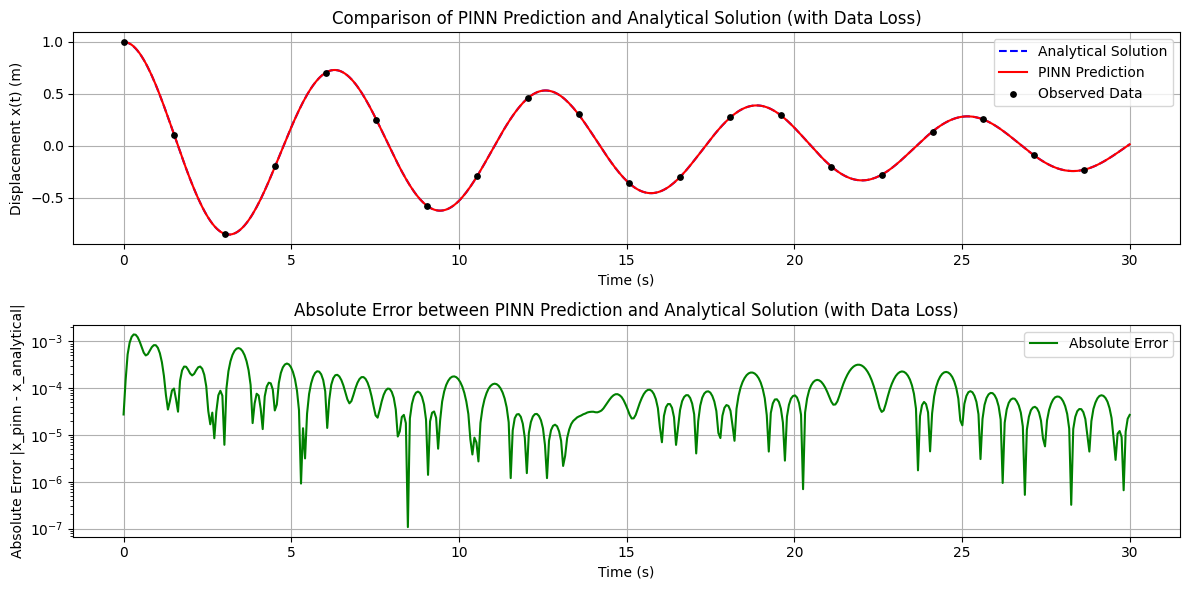

In [19]:
#@title PINN Prediction vs. Analytical Solution Plot
import matplotlib.pyplot as plt

t_eval = np.linspace(t_min, t_max, 500)
t_eval_tf = tf.constant(t_eval, dtype=tf.float32)
t_eval_reshaped = tf.reshape(t_eval_tf, (-1, 1))

x_pinn_pred = model(t_eval_reshaped).numpy().flatten()

x_analytical_eval = analytical_solution(t_eval, m, k, c, x0, v0)

absolute_error = np.abs(x_pinn_pred - x_analytical_eval)

print(f"Max absolute error:  {absolute_error.max():.3e}")
print(f"Mean absolute error: {absolute_error.mean():.3e}")
print(f"RMSE:                {np.sqrt(np.mean((x_pinn_pred - x_analytical_eval)**2)):.3e}")

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t_eval, x_analytical_eval, label='Analytical Solution', color='blue', linestyle='--')
plt.plot(t_eval, x_pinn_pred, label='PINN Prediction', color='red')
plt.scatter(t_train_data_np, x_train_data_np, label='Observed Data', color='black', s=15, zorder=5)
plt.title('Comparison of PINN Prediction and Analytical Solution (with Data Loss)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement x(t) (m)')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogy(t_eval, absolute_error, label='Absolute Error', color='green')
plt.title('Absolute Error between PINN Prediction and Analytical Solution (with Data Loss)')
plt.xlabel('Time (s)')
plt.ylabel('Absolute Error |x_pinn - x_analytical|')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 10. Loss curves

Each term plotted separately.

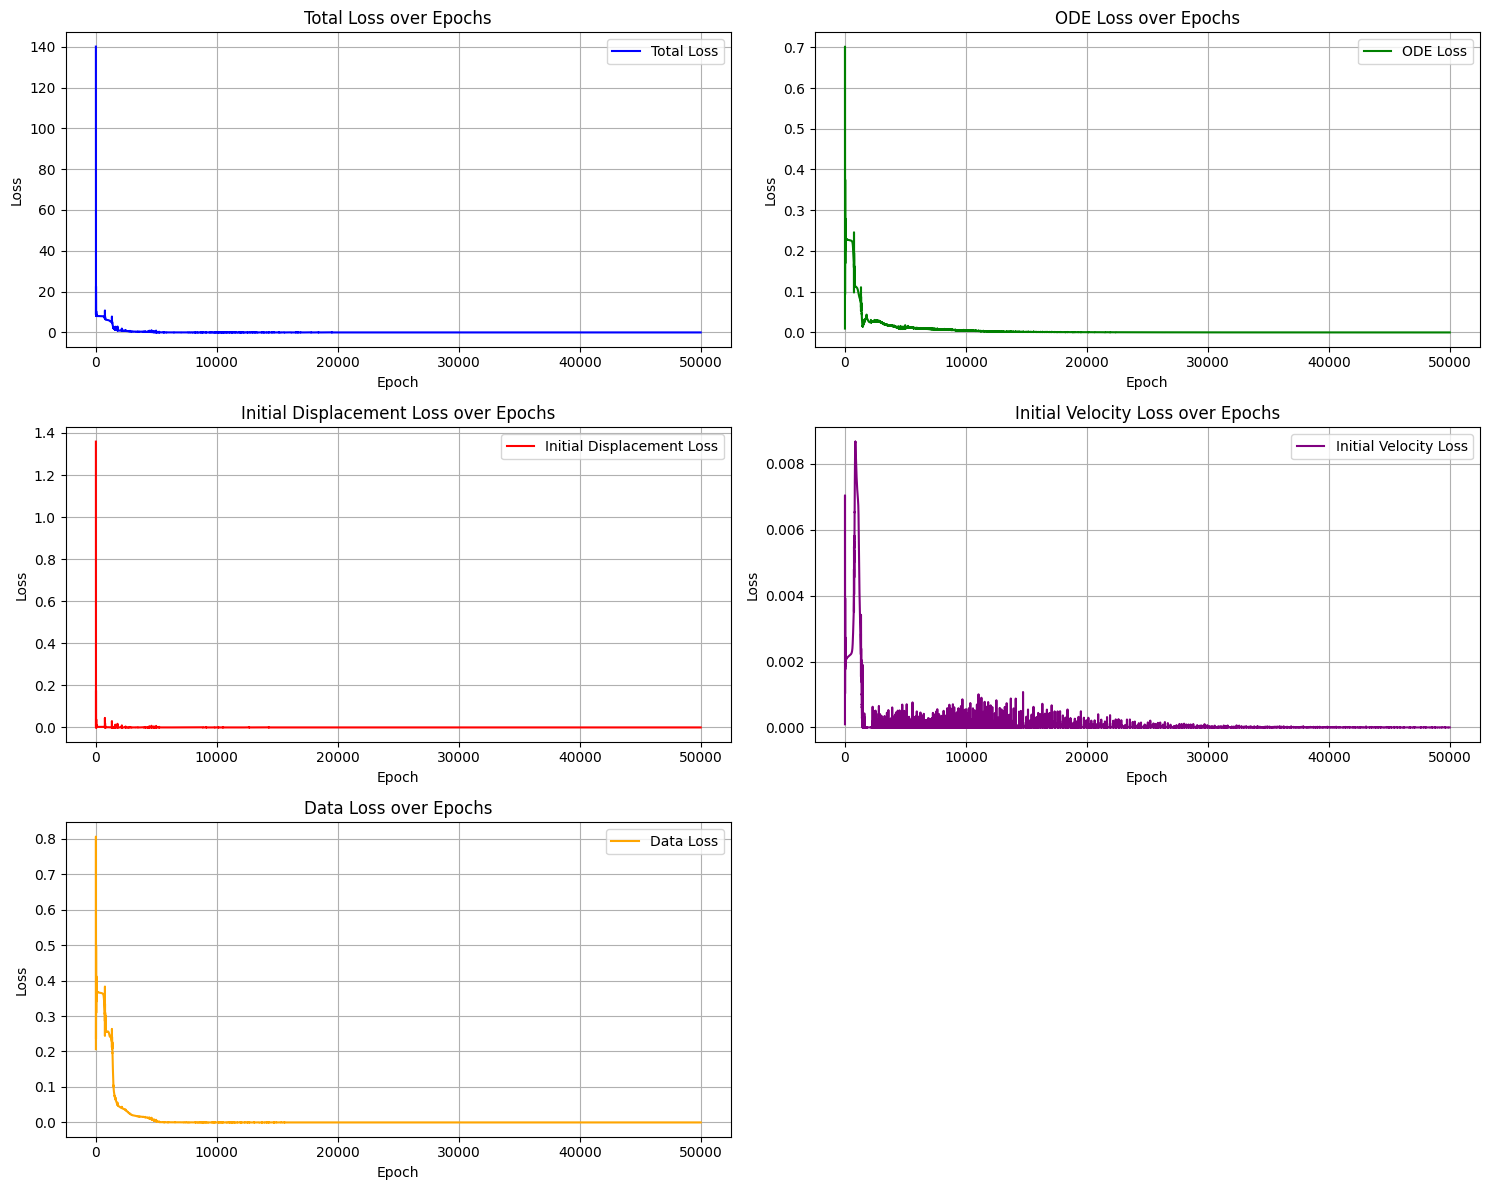

In [20]:
#@title Various Loss Graphs
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

# Plot Total Loss
plt.subplot(3, 2, 1)
plt.plot(history['epoch'], history['total_loss'], label='Total Loss', color='blue')
plt.title('Total Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(3, 2, 2)
plt.plot(history['epoch'], history['ode_loss'], label='ODE Loss', color='green')
plt.title('ODE Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(3, 2, 3)
plt.plot(history['epoch'], history['ic_disp_loss'], label='Initial Displacement Loss', color='red')
plt.title('Initial Displacement Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(3, 2, 4)
plt.plot(history['epoch'], history['ic_vel_loss'], label='Initial Velocity Loss', color='purple')
plt.title('Initial Velocity Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(3, 2, 5)
plt.plot(history['epoch'], history['data_loss'], label='Data Loss', color='orange')
plt.title('Data Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
